In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg
from scipy.sparse.linalg import eigsh

import utils
import w4_unittest

In [2]:
imgs = utils.load_images('./data/')


In [3]:
height, width = imgs[0].shape
print(f'\n Your dataset has {len(imgs)} images of size {height}{width} pixels\n')


 Your dataset has 55 images of size 6464 pixels



In [4]:
#lets check pixels of each images
m=55
for t in range(m):
    h, w = imgs[t].shape
    print(f'Image {t} is of size {h}x{w} pixels')

print("\n ALL PIXELS ARE GIVEN ABOVE !! ")

Image 0 is of size 64x64 pixels
Image 1 is of size 64x64 pixels
Image 2 is of size 64x64 pixels
Image 3 is of size 64x64 pixels
Image 4 is of size 64x64 pixels
Image 5 is of size 64x64 pixels
Image 6 is of size 64x64 pixels
Image 7 is of size 64x64 pixels
Image 8 is of size 64x64 pixels
Image 9 is of size 64x64 pixels
Image 10 is of size 64x64 pixels
Image 11 is of size 64x64 pixels
Image 12 is of size 64x64 pixels
Image 13 is of size 64x64 pixels
Image 14 is of size 64x64 pixels
Image 15 is of size 64x64 pixels
Image 16 is of size 64x64 pixels
Image 17 is of size 64x64 pixels
Image 18 is of size 64x64 pixels
Image 19 is of size 64x64 pixels
Image 20 is of size 64x64 pixels
Image 21 is of size 64x64 pixels
Image 22 is of size 64x64 pixels
Image 23 is of size 64x64 pixels
Image 24 is of size 64x64 pixels
Image 25 is of size 64x64 pixels
Image 26 is of size 64x64 pixels
Image 27 is of size 64x64 pixels
Image 28 is of size 64x64 pixels
Image 29 is of size 64x64 pixels
Image 30 is of size 

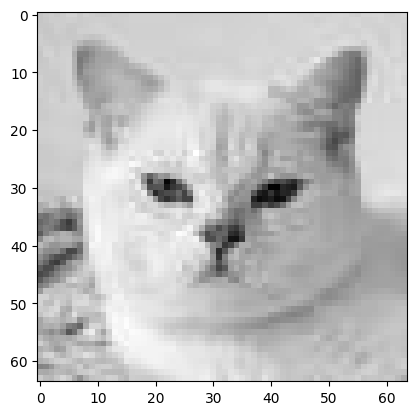

In [5]:
#plot one image to see what they look like. You can use the colormap 'gray' to plot in black and white
plt.imshow(imgs[0], cmap='gray')

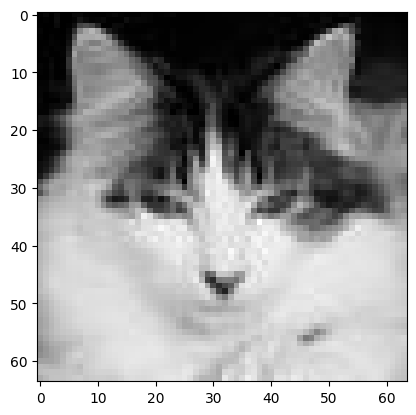

In [6]:
plt.imshow(imgs[50], cmap='gray')

In [7]:
imgs_flatten = np.array([im.reshape(-1) for im in imgs] )
print(f'imgs_flaten shape: {imgs_flatten.shape}')

#1) imgs → A list (or array) of images, where each image is stored as a 2D matrix (e.g., 64×64 pixels).
#2) im.reshape(-1) → Takes one image (im) and flattens it into a 1D row (e.g., turns 64×64 into 4096 numbers).
#3)reshape(-1) means: "Flatten this into a single row, and let NumPy figure out the size."
#4)[ ... for im in imgs ] → Does this for every image in imgs, creating a list of flattened rows.
#5)np.array([...]) → Converts the list of flattened images into a NumPy array.
#6)imgs_flatten.shape → Prints the shape of the final array.



imgs_flaten shape: (55, 4096)


In [8]:
#Get the covariance matrix

In [9]:
#In order to get the covariance matrix you first need to center the data by subtracting the mean for each variable (column).
#To perform the centering you will need three numpy functions. Click on their names if you want to read the official documentation,
#for each in more detail:

# 1)np.mean: use this function to compute the mean of each variable, just remember to pass the correct axis argument.
# 2)np.repeat: This will allow for you to repeat the values of each  𝜇𝑖.
# 3)np.reshape: Use this function to reshape the repeated values into a matrix of shape the same size as your input data
#To get the correct matrix after the reshape, remember to use the parameter order='F'.

In [10]:
def center_Data(Y):
    mean_vec= np.mean(Y, axis=0)
    mean_mat = np.reshape(mean_vec, (1,-1), order='F')
    mean_mat = np.tile(mean_mat, (Y.shape[0], 1))

    X = Y - mean_mat
    return X

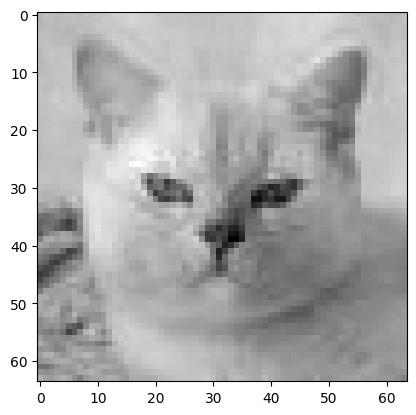

In [11]:
X = center_Data(imgs_flatten)
plt.imshow(X[0].reshape(64,64), cmap='gray')

In [12]:
# Test your solution.
w4_unittest.test_center_data(center_Data)

 All tests passed


In [13]:
def get_cov_matrix(X):
    cov_matrix = np.dot(X.T, X) / (X.shape[0] -1)
    return cov_matrix

In [14]:
cov_matrix = get_cov_matrix(X)

In [15]:
print(f'Covariance matrix shape: {cov_matrix.shape}')

Covariance matrix shape: (4096, 4096)


In [16]:
# Test your solution.
w4_unittest.test_cov_matrix(get_cov_matrix)

 All tests passed


In [17]:
#The random seed is fixed in the code above to help ensure the same eigenvectors
#are calculated each time. This is because for each eigenvector, there are actually
#two possible outcomes with norm 1. They fall on the same line but point in opposite 
#directions. An example of this would be the vectors

In [20]:
# Set random seed for reproducibility (using NumPy)
np.random.seed(7)
# Compute eigenvalues and eigenvectors
eigenvals, eigenvecs = scipy.sparse.linalg.eigsh(cov_matrix, k=55)
# Print the 10 largest eigenvalues (since eigsh returns in ascending order)
print(f'Ten largest eigenvalues: \n{eigenvals[-10:]}')


Ten largest eigenvalues: 
[ 293228.19669624  383726.58867454  399184.59618649  479311.0892984
  839689.08870292  878711.73402995 1011093.05519076 1536617.26289103
 2483710.87630303 4199357.2773408 ]


In [24]:
# Reverse to get descending order (largest first)
eigenvals = eigenvals[::-1]
eigenvecs = eigenvecs[:, ::-1]
print(f'Ten largest eigenvalues: \n{eigenvals[:10]}')
print(f'Ten largest eigenvevtors: \n{eigenvecs[:10]}')

Ten largest eigenvalues: 
[4199357.2773408  2483710.87630303 1536617.26289103 1011093.05519076
  878711.73402995  839689.08870292  479311.0892984   399184.59618649
  383726.58867454  293228.19669624]
Ten largest eigenvevtors: 
[[-1.09712142e-02 -1.11129296e-02  1.13973250e-02 -2.20500672e-02
   4.83977851e-03 -3.02764921e-02 -1.26203785e-02  2.95685288e-02
  -8.78836477e-04 -7.00568410e-03  2.55154528e-02 -3.65329248e-02
  -9.07185656e-03  3.56380511e-02 -5.39333656e-03  3.90091744e-03
   3.23571971e-02  4.34717289e-03  1.28908928e-02 -1.35986226e-02
  -1.73722200e-03 -5.03736359e-03  9.49659441e-03  2.01467192e-02
   4.39095828e-03 -3.47447741e-02 -2.23334851e-02  2.32686056e-03
  -2.28464505e-02 -6.63252472e-03  5.60023576e-03  8.91884529e-03
   5.42933943e-03 -3.04640971e-03 -2.83386010e-02 -3.18074030e-02
  -5.01358123e-03  2.88673924e-02 -5.06511226e-03  9.76181838e-03
   9.99519644e-03  5.70987593e-03 -1.80193885e-02  7.78644895e-03
  -4.65684195e-03 -7.04461447e-03 -9.99184464e-

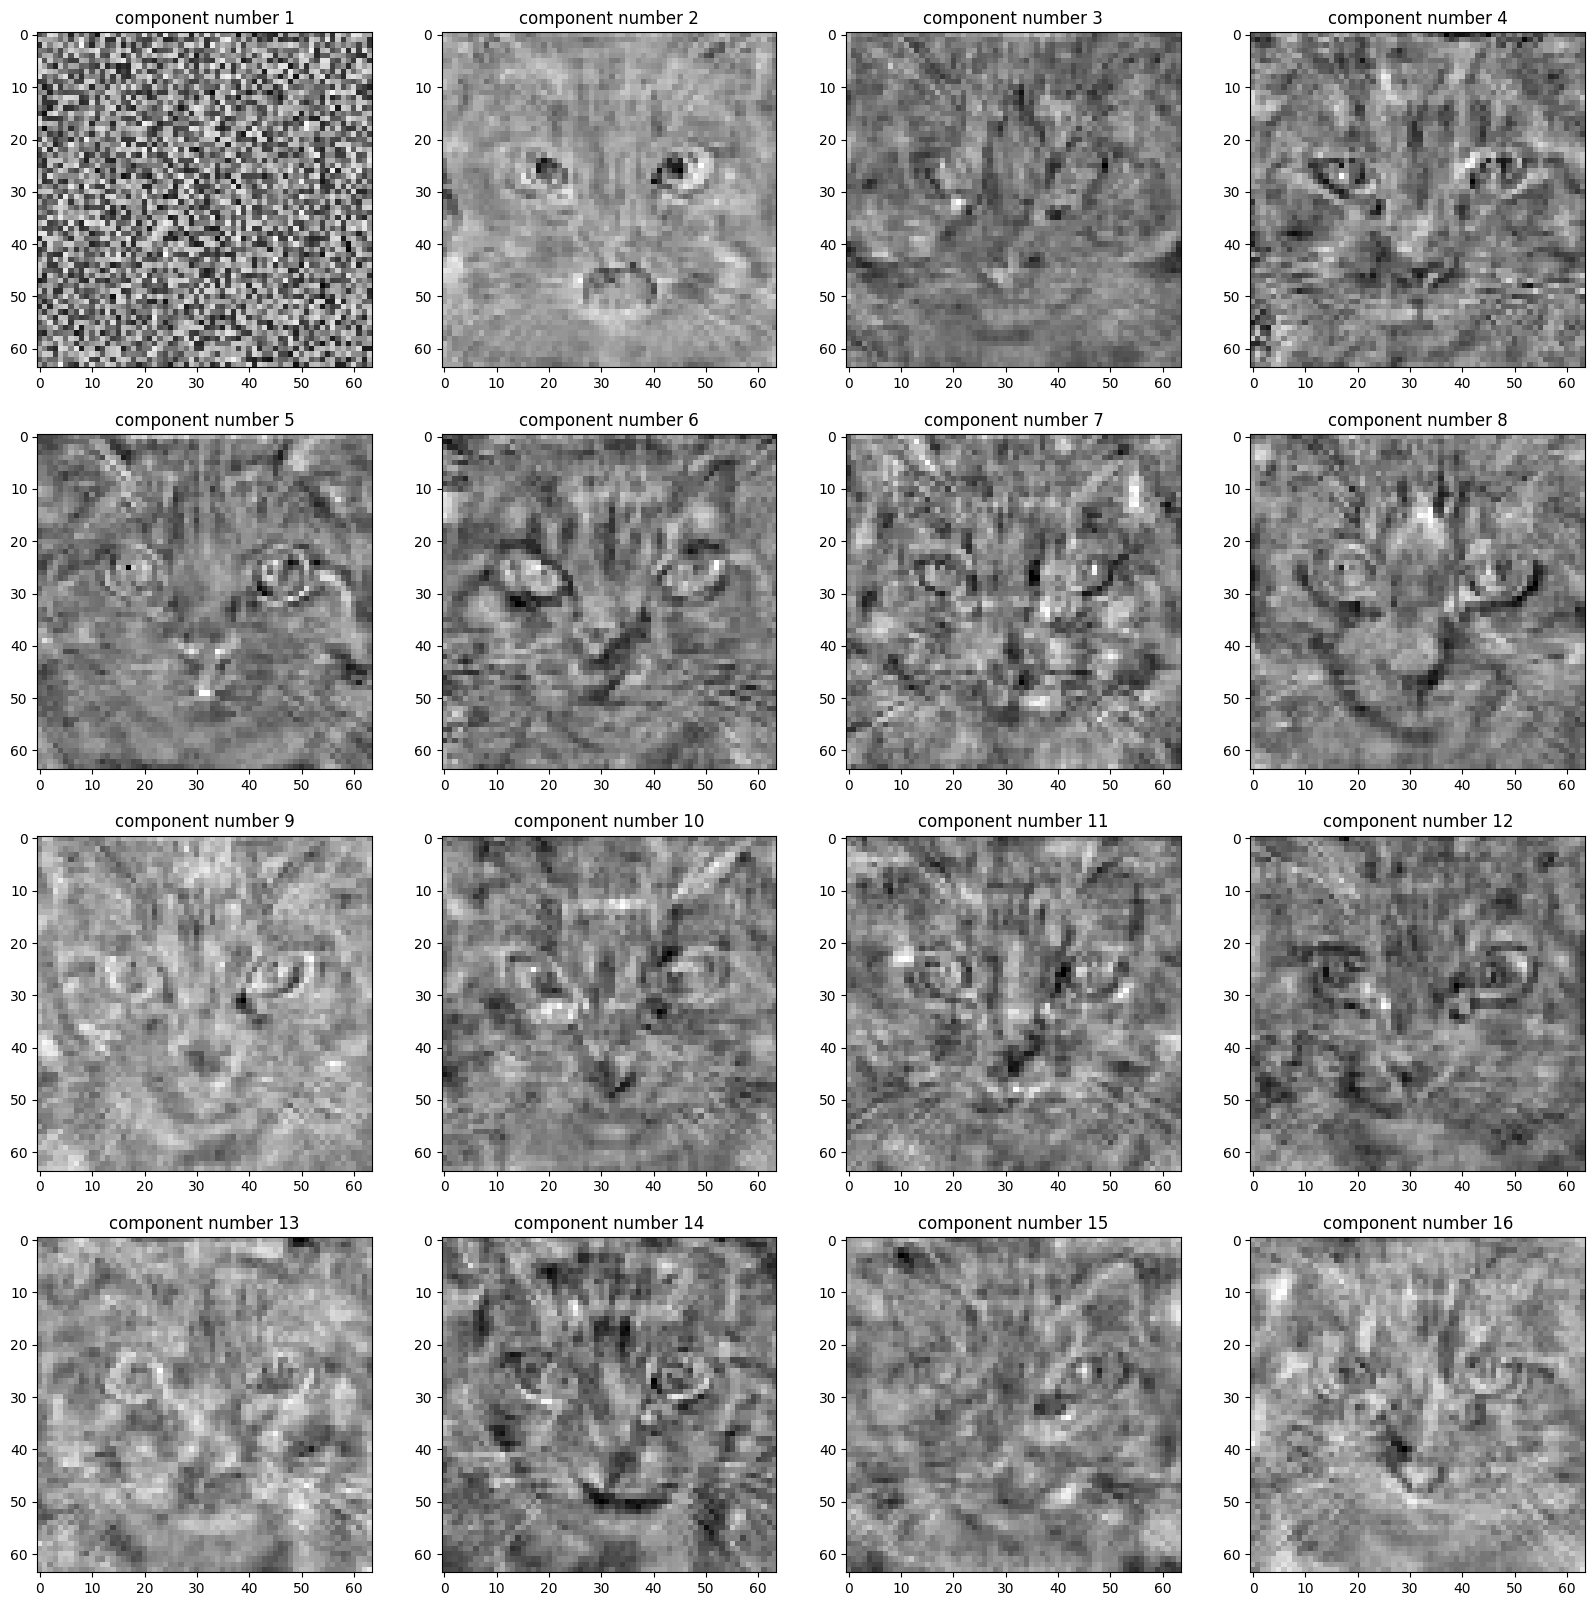

In [23]:
#visualizing the first sixteen components
fig, ax = plt.subplots(4,4, figsize=(20,20))
for n in range(4):
    for k in range(4):
        ax[n,k].imshow(eigenvecs[:,n*4+k].reshape(height,width), cmap='gray')
        ax[n,k].set_title(f'component number {n*4+k+1}')

In [ ]:
#a function that, given the data matrix, the eigenvector matrix
#(always sorted according to decreasing eignevalues),
#and the number of principal components to use, performs PCA.

In [25]:
def perform_PCA(X, eigenvecs, k):
    # Select the top k eigenvectors (first k columns since they're sorted descending)
    V = eigenvecs[:, :k]
    # Project the data onto the principal components
    Xred = np.dot(X, V)
    return Xred

In [26]:
#Trying out this function, reducing your data to just two components

In [27]:
Xred2 = perform_PCA(X, eigenvecs,2)
print(f'Xred2 shape: {Xred2.shape}')

Xred2 shape: (55, 2)


In [28]:
# Test your solution.
w4_unittest.test_check_PCA(perform_PCA)

 All tests passed


In [31]:
#One cool thing about reducing your data to just two components is that you
#can clearly visualize each cat image on the plane. Remember that each axis on
#this new plane represents a linear combination of the original variables,
#given by the direction of the two eigenvectors.

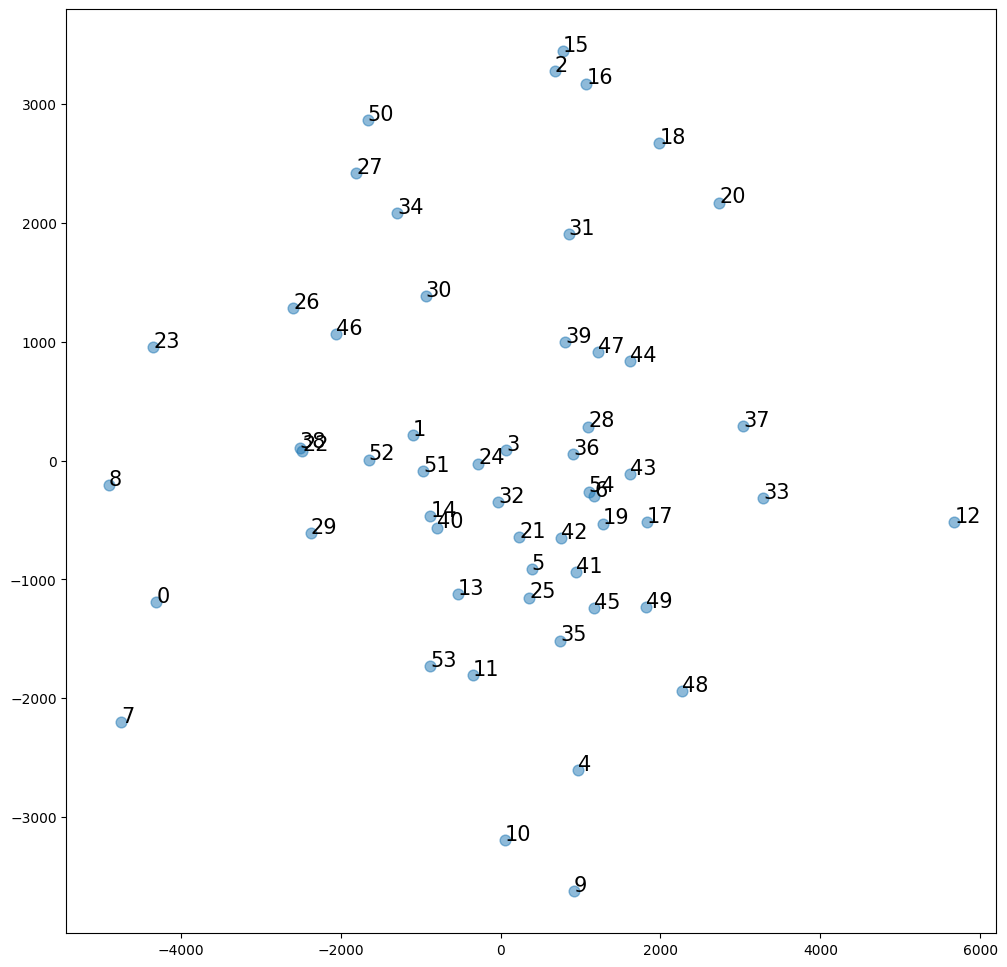

In [29]:
utils.plot_reduced_data(Xred2)

In [32]:
#Use the function `plot_reduced_data` in `utils`to visualize the transformed data.
#Each blue dot represents an image, and the number represents the index of the image.
#This is so you can later recover which image is which, and gain some intuition.

In [33]:
#If two points end up being close to each other in this representation,
#it is expected that the original pictures should be similar as well.
#Let's see if this is true. Consider for example the images 19, 21 and 41,
#which appear close to each other on the top center of the plot. 
#Plot the corresponding cat images vertfy that they correspond to similar cats.

Text(0.5, 0.98, 'Similar cats')

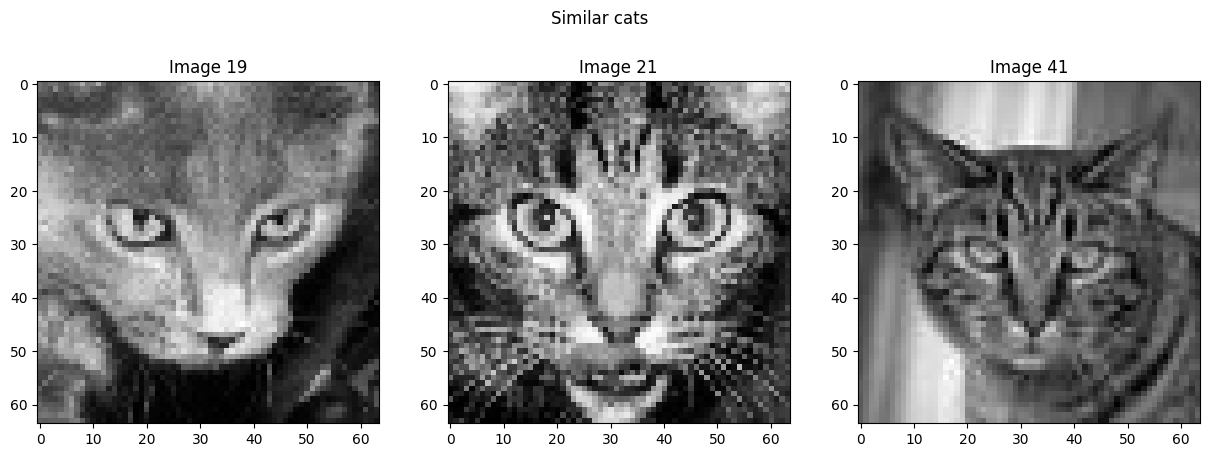

In [34]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(imgs[19], cmap='gray')
ax[0].set_title('Image 19')
ax[1].imshow(imgs[21], cmap='gray')
ax[1].set_title('Image 21')
ax[2].imshow(imgs[41], cmap='gray')
ax[2].set_title('Image 41')
plt.suptitle('Similar cats')

In [35]:
#As you can see, all three cats have white snouts and black fur around the eyes,
#making them pretty similar.

In [37]:
#Now, let's choose three images that seem far appart from each other,
#for example image 18, on the middle right,
#41 on the top center and 51 on the lower left, and also plot the images

Text(0.5, 0.98, 'Different cats')

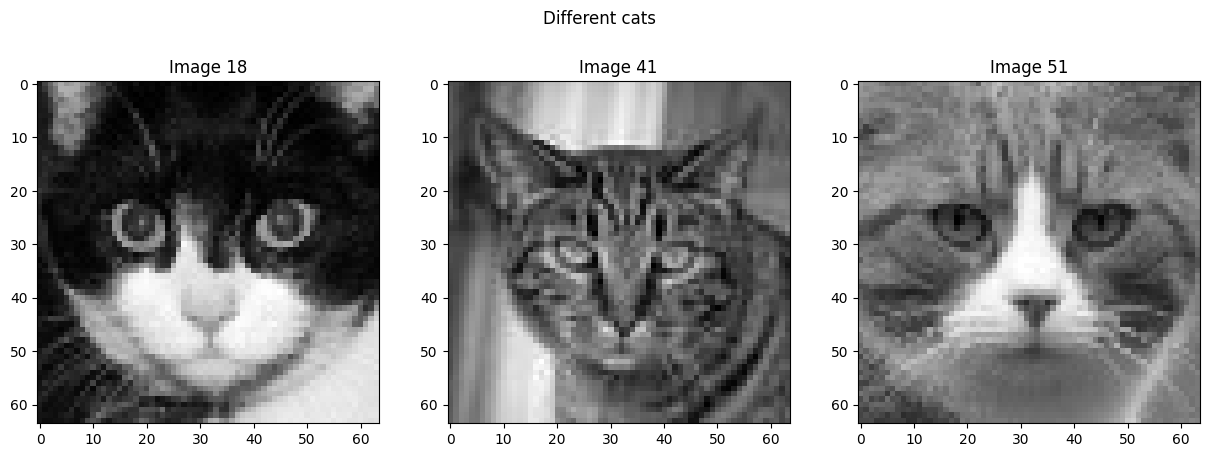

In [38]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(imgs[18], cmap='gray')
ax[0].set_title('Image 18')
ax[1].imshow(imgs[41], cmap='gray')
ax[1].set_title('Image 41')
ax[2].imshow(imgs[51], cmap='gray')
ax[2].set_title('Image 51')
plt.suptitle('Different cats')

In [39]:
#In this case, all three cats look really different, one being completely black,
#another completely white, and the the third one a mix of both colors.

In [40]:
###***Reconstructing the images from the eigenvectors

In [41]:
#When you compress the images using PCA, you are losing some information 
#because you are using fewer variables to represent each observation.
#Q)hen how many components do you need to get a good reconstruction of the image?

In [42]:
#A cool thing is that with a simple dot product you can transform the data after 
#applying PCA back to the original space. This means that you can reconstruct the 
#original image from the transformed space and check how distorted it looks
#based on the number of components you kept.

In [43]:
#Suppose you obtained the matrix  𝑋𝑟𝑒𝑑
 # by keeping just two eigenvectors, then  𝑋𝑟𝑒𝑑=X[𝑣1 𝑣2]⏟𝑽2
 #.

#To transform the images back to the original variables space all you need to do is take the dot product between  𝑋𝑟𝑒𝑑
 # and  𝑽𝑇2
 #. If you were to keep more components, say  𝑘
# , then simply replace  𝑽2
 # by  𝑽𝒌=[𝑣1 𝑣2 … 𝑣𝑘]
 #.

In [44]:
#In this cell you will define a function that given the transformed data  𝑋𝑟𝑒𝑑
 # and the matrix of eigenvectors returns the recovered image.

def reconstruct_image(Xred, eigenvecs):
    X_reconstructed = Xred.dot(eigenvecs[:,:Xred.shape[1]].T)

    return X_reconstructed


In [45]:
#let's see what the reconstructed image looks like for different number of principalcomponents

Text(0.5, 1.0, 'reconstructed from 30 components')

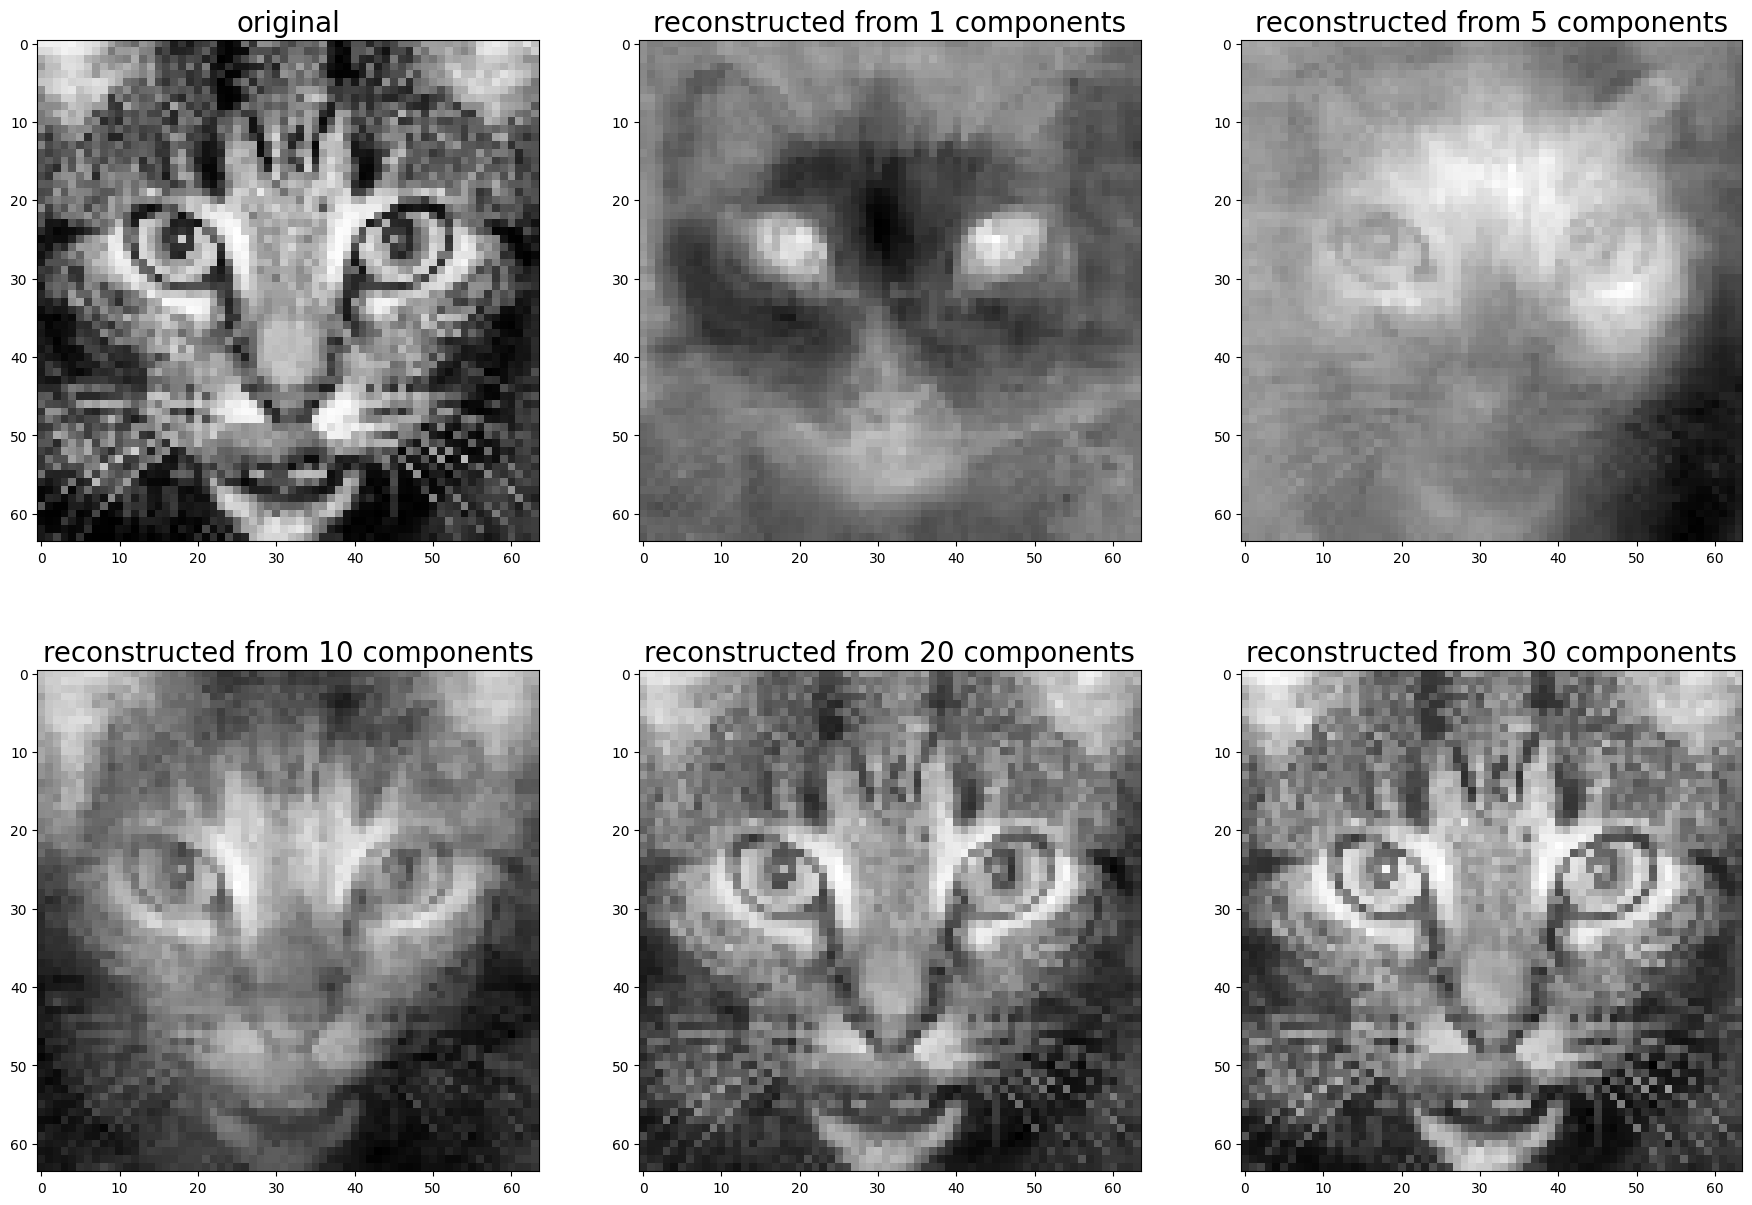

In [46]:
Xred1 = perform_PCA(X, eigenvecs,1) # reduce dimensions to 1 component
Xred5 = perform_PCA(X, eigenvecs, 5) # reduce dimensions to 5 components
Xred10 = perform_PCA(X, eigenvecs, 10) # reduce dimensions to 10 components
Xred20 = perform_PCA(X, eigenvecs, 20) # reduce dimensions to 20 components
Xred30 = perform_PCA(X, eigenvecs, 30) # reduce dimensions to 30 components
Xrec1 = reconstruct_image(Xred1, eigenvecs) # reconstruct image from 1 component
Xrec5 = reconstruct_image(Xred5, eigenvecs) # reconstruct image from 5 components
Xrec10 = reconstruct_image(Xred10, eigenvecs) # reconstruct image from 10 components
Xrec20 = reconstruct_image(Xred20, eigenvecs) # reconstruct image from 20 components
Xrec30 = reconstruct_image(Xred30, eigenvecs) # reconstruct image from 30 components

fig, ax = plt.subplots(2,3, figsize=(22,15))
ax[0,0].imshow(imgs[21], cmap='gray')
ax[0,0].set_title('original', size=20)
ax[0,1].imshow(Xrec1[21].reshape(height,width), cmap='gray')
ax[0,1].set_title('reconstructed from 1 components', size=20)
ax[0,2].imshow(Xrec5[21].reshape(height,width), cmap='gray')
ax[0,2].set_title('reconstructed from 5 components', size=20)
ax[1,0].imshow(Xrec10[21].reshape(height,width), cmap='gray')
ax[1,0].set_title('reconstructed from 10 components', size=20)
ax[1,1].imshow(Xrec20[21].reshape(height,width), cmap='gray')
ax[1,1].set_title('reconstructed from 20 components', size=20)
ax[1,2].imshow(Xrec30[21].reshape(height,width), cmap='gray')
ax[1,2].set_title('reconstructed from 30 components', size=20)


In [47]:
#As you can see, as the number of components increases, the reconstructed image looks
#more and more as the original one

In [48]:
#Explained variance
#When deciding how many components to use for the dimensionality reduction, 
#one good criteria to consider is the explained variance.

#The explained variance is measure of how much variation in a dataset 
#can be attributed to each of the principal components (eigenvectors). 
#In other words, it tells us how much of the total variance is “explained” by 
#each component.

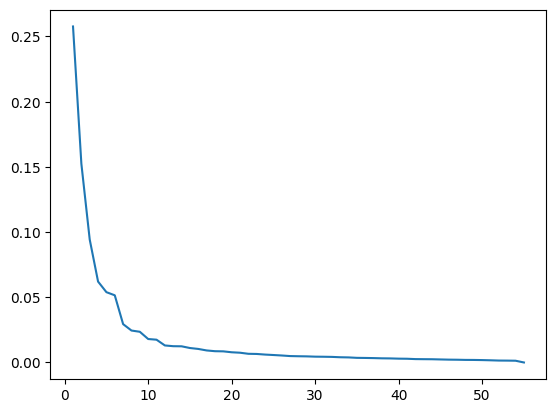

In [49]:
explained_variance = eigenvals/sum(eigenvals)
plt.plot(np.arange(1,56), explained_variance)

In [50]:
#As you can see, the explained variance falls pretty fast, and is very small after 
#the 20th component.
#A good way to decide on the number of components is to keep the ones that 
#explain a very high percentage of the variance, for example 95%.
#For an easier visualization you can plot the cumulative explained variance. 
#You can do this with the np.cumsum function. Let's see what this looks like

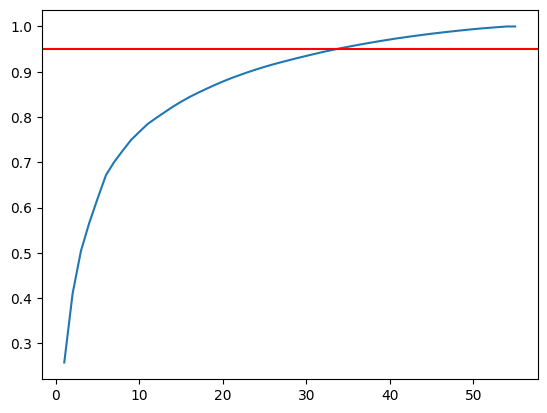

In [51]:
explained_cum_variance = np.cumsum(explained_variance)
plt.plot(np.arange(1,56), explained_cum_variance)
plt.axhline(y=0.95, color='r')

In [52]:
#In red you can see the 95% line. This means that if you want 
#to be able to explain 95% of the variancee of your data you need to keep 35 
#principal components.
#Let's see how some of the original images look after the reconstruction when 
#using 35 principal components

Text(0.5, 1.0, 'Reconstructed')

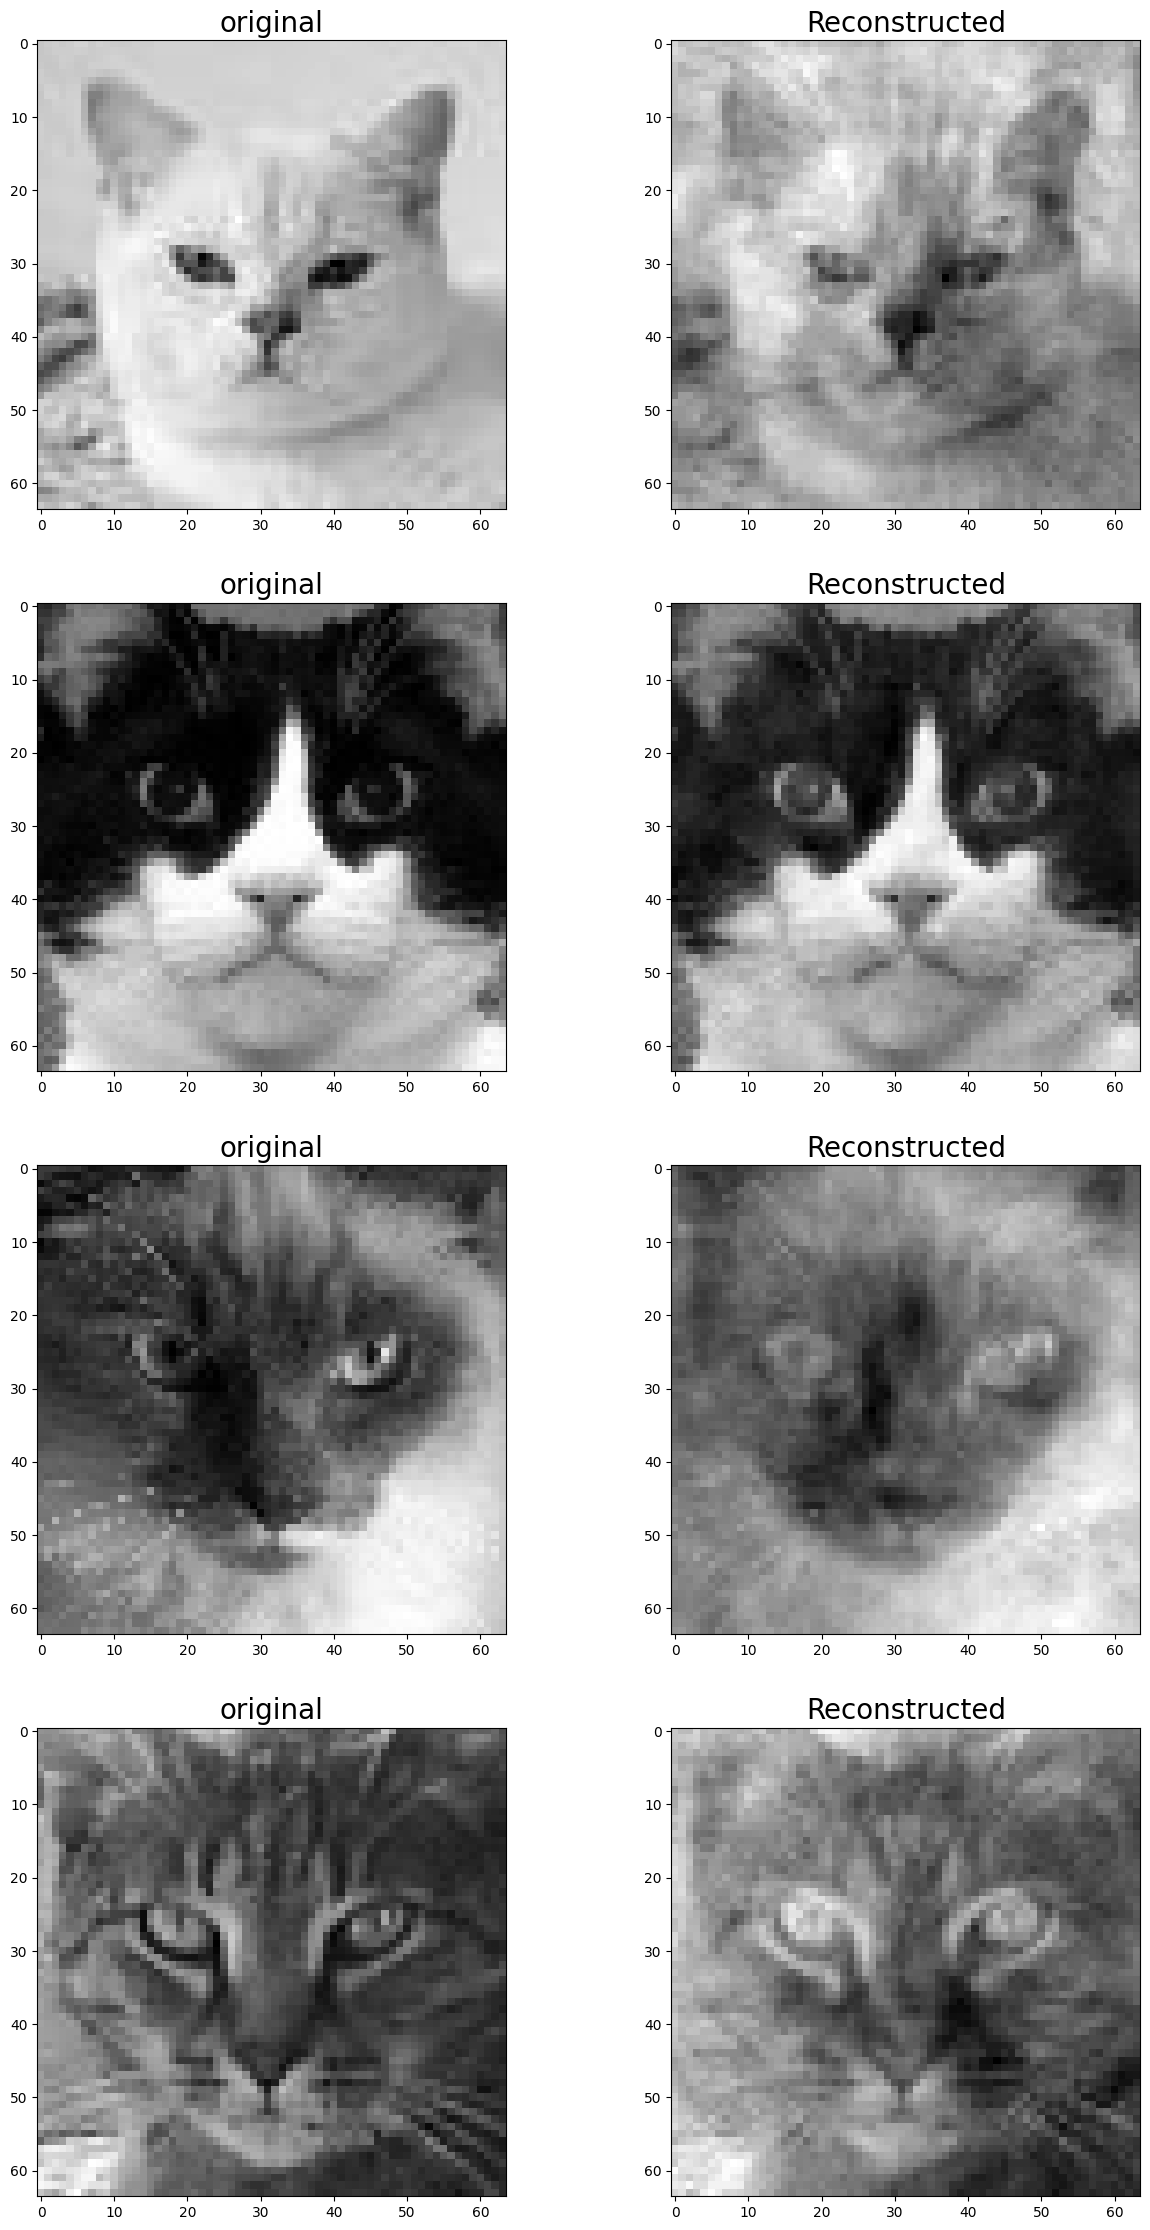

In [53]:
Xred35 = perform_PCA(X, eigenvecs, 35) # reduce dimensions to 35 components
Xrec35 = reconstruct_image(Xred35, eigenvecs) # reconstruct image from 35 components

fig, ax = plt.subplots(4,2, figsize=(15,28))
ax[0,0].imshow(imgs[0], cmap='gray')
ax[0,0].set_title('original', size=20)
ax[0,1].imshow(Xrec35[0].reshape(height, width), cmap='gray')
ax[0,1].set_title('Reconstructed', size=20)

ax[1,0].imshow(imgs[15], cmap='gray')
ax[1,0].set_title('original', size=20)
ax[1,1].imshow(Xrec35[15].reshape(height, width), cmap='gray')
ax[1,1].set_title('Reconstructed', size=20)

ax[2,0].imshow(imgs[32], cmap='gray')
ax[2,0].set_title('original', size=20)
ax[2,1].imshow(Xrec35[32].reshape(height, width), cmap='gray')
ax[2,1].set_title('Reconstructed', size=20)

ax[3,0].imshow(imgs[54], cmap='gray')
ax[3,0].set_title('original', size=20)
ax[3,1].imshow(Xrec35[54].reshape(height, width), cmap='gray')
ax[3,1].set_title('Reconstructed', size=20)


In [ ]:
#Most of these reconstructions look pretty good, and you were able to save a lot
#of memory by reducing the data from 4096 variables to just 35!